# BEE 4750 Homework 1: Introduction to Using Julia

**Name**:

**ID**:

> **Due Date**
>
> Thursday, 9/11/25, 9:00pm

## Overview

### Instructions

-   Problem 1 consist of a series of code snippets for you to interpret
    and debug. You will be asked to identify relevant error(s) and fix
    the code.
-   Problem 2 asks you to write code to implement several simple
    functions using more general programming and some which are unique
    to Julia (which might mean that you need to look at the
    documentation or use Julia’s help function, which is accessed with
    `?`, e.g. `?sum` for help with the `sum()` function) or to analyze
    Julia syntax.
-   Problem 3 asks you to convert a verbal description of a wastewater
    treatment system into a Julia function, and then to use that
    function to explore the impact of different wastewater allocation
    strategies.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [15]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Desktop/Cornell_Courses/FA_25/BEE_4750/bee4750-hw1-xl748`


Standard Julia practice is to load all needed packages at the top of a
file. If you need to load any additional packages in any assignments
beyond those which are loaded by default, feel free to add a `using`
statement, though [you may need to install the
package](https://viveks.me/environmental-systems-analysis/tutorials/julia-basics.html#package-management).

In [16]:
using Random
using Plots
using GraphRecipes
using LaTeXStrings
using Distributions

In [17]:
# this sets a random seed, which ensures reproducibility of random number generation. You should always set a seed when working with random numbers.
Random.seed!(1)

TaskLocalRNG()

## Problems (Total: 30 Points)

### Problem 1 (12 points)

The following subproblems all involve code snippets that require
debugging. You are encouraged to use online resources (*e.g.* Julia
documentation and forums, Stack Overflow, Reddit, etc) to help find
diagnose error messages and find solutions, but make sure that you
clearly document which resources you used and how you used them.

#### Problem 1.1

You’ve been tasked with writing code to identify the minimum value in an
array. You cannot use a predefined function. Your colleague suggested
the function below, but it does not return the minimum value.

In [18]:
function minimum(array)
    # initialize the minimum value counter
    min_value = 0
    # update minimum values
    for i in 1:length(array)
        if array[i] < min_value
            min_value = array[i]
        end
    end
    # return found minimum
    return min_value
end

array_values = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
@show minimum(array_values);

minimum(array_values) = 0


What is the logical flaw in the code? Fix it and show that your fixed
code solves the problem.

### Writeup
The problem of this code is that the `min_value` is reset to 0 every time at the beginning of the function. When applying the `minimum` function to every item in the `array_values` list, they are always being compared to 0, and nothing was being saved, so the returned value is also 0. The code I changed set the minimum value to start at the first position of the list, thus allowing every following item since position 2 able to get compared to the previous value, and if the new value is smaller than the current minimum value, it will become the new value. So, in this case, the smallest integer in the list is 78. 

In [19]:
# Fixed code
function minimum(array)
    # initialize the minimum value counter
    min_value = array[1]
    # update minimum values
    for i in 2:length(array)
        if array[i] < min_value
            min_value = array[i]
        end
    end
    # return found minimum
    return min_value
end

array_values = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
@show minimum(array_values);

minimum(array_values) = 78


#### Problem 1.2

Your team is trying to compute the average grade for your class, but the
following code produces an `UndefVarError`.

In [20]:
# enter student grade vector
student_grades = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
# compute class average
function class_average(grades)
  average_grade = mean(student_grades)
  return average_grade
end

@show average_grade;

UndefVarError: UndefVarError: `average_grade` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

What does this `UndefVarError` mean? Why does this code produce one? Fix
the error and solve the problem.

### Writeup
The `UndefVarError` is resulted from an unfound or undefined variable name, as signified by the error text. The error text mentions about how `average_age` is not found, which is because of how it is defined in the function. Because `average_age` equals the mean of `student_grades`, and the latter does not exist inside the function `class_average`, `average_age` is consequentily also not existing. My fixed code changes `student_grades` to be `grades`, which is the defined input variable for the function `class_average`. The calculated average for this list is 94.4. 

In [21]:
# Fixed code
# enter student grade vector
student_grades = [89, 90, 95, 100, 100, 78, 99, 98, 100, 95]
# compute class average
function class_average(grades)
  average_grade = mean(grades)
  return average_grade
end

@show class_average(student_grades);

class_average(student_grades) = 94.4


#### Problem 1.3

Your team wants to know the expected payout of an old Italian dice game
called *passadieci* (which was analyzed by Galileo as one of the first
examples of a rigorous study of probability). The goal of passadieci is
to get at least an 11 from rolling three fair, six-sided dice. Your
strategy is to compute the average wins from 1,000 trials, but the code
you’ve written below produces a `MethodError`.

In [22]:
# function to simulate a passadieci roll: 3 6-sided dice
function passadieci()
    # this rand() call samples 3 values from the vector [1, 6]
    roll = rand(1:6, 3) 
    return roll
end
# set number of trials and initialize outcome vector
n_trials = 1_000
outcomes = zero(n_trials)
# simulate number of passadieci rolls and count wins
for i = 1:n_trials
    outcomes[i] = (sum(passadieci()) > 11)
end
win_prob = sum(outcomes) / n_trials # compute average number of wins
@show win_prob;

MethodError: MethodError: no method matching setindex!(::Int64, ::Bool, ::Int64)
The function `setindex!` exists, but no method is defined for this combination of argument types.

What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

### Writeup
I searched up and understood the `zero` function in Julia is used to return the additive identity of the input, which in this case, `outcomes` will turn out to be a single value which is 0. Since we want a list, this will not work. My fixed code changed it to use `zeros`, which creates a list of length 1000 and full of 0 as the integer type. Then `outcomes` can be updated in the loop each time. The final probability for winning fluctuates mainly from 35% to 40%.

In [23]:
# Fixed code
# function to simulate a passadieci roll: 3 6-sided dice
function passadieci()
    # this rand() call samples 3 values from the vector [1, 6]
    roll = rand(1:6, 3) 
    return roll
end
# set number of trials and initialize outcome vector
n_trials = 1_000
outcomes = zeros(Int, n_trials)
# simulate number of passadieci rolls and count wins
for i = 1:n_trials
    outcomes[i] = (sum(passadieci()) > 11)
end
win_prob = sum(outcomes) / n_trials # compute average number of wins
@show win_prob;

win_prob = 0.382


#### Problem 1.4

You’re interested in writing some code to remove the mean of a vector
from all of its components. You’ve written the following code and tried
to test it on a random vector, but your code returns a `MethodError`.

In [24]:
# function to remove mean from a vector
function remove_mean(vect)
    # fucntion to compute the mean
    function compute_mean(vect)
        element_sum = 0 # initialize sum
        # compute mean and return
        for v in vect
            element_sum += v
        end
        return element_sum / length(vect)
    end

    m = compute_mean(vect) # compute mean
    # return demeaned vector
    return vect - m
end

random_vect = rand(1_000)
@show remove_mean(random_vect)

MethodError: MethodError: no method matching -(::Vector{Float64}, ::Float64)
For element-wise subtraction, use broadcasting with dot syntax: array .- scalar
The function `-` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  -(!Matched::ChainRulesCore.NoTangent, ::Any)
   @ ChainRulesCore ~/.julia/packages/ChainRulesCore/XAgYn/src/tangent_arithmetic.jl:61
  -(::Any, !Matched::ChainRulesCore.NotImplemented)
   @ ChainRulesCore ~/.julia/packages/ChainRulesCore/XAgYn/src/tangent_arithmetic.jl:50
  -(!Matched::ChainRulesCore.ZeroTangent, ::Any)
   @ ChainRulesCore ~/.julia/packages/ChainRulesCore/XAgYn/src/tangent_arithmetic.jl:101
  ...


What does this `MethodError` mean? Why does this code produce one? Fix
the error and solve the problem.

### Writeup
The error happens when the vector `vect` is trying to subtract a single value `m`. In order to operate this constant subtracting process for every item of the vector, Julia requires a `.` in front of the operator, which is what happened in my fixed code, where I have `vect .- m`. The output is the updated vector with 1,000 components, with each component subtracted the mean value already.

In [25]:
# Fixed code
# function to remove mean from a vector
function remove_mean(vect)
    # fucntion to compute the mean
    function compute_mean(vect)
        element_sum = 0 # initialize sum
        # compute mean and return
        for v in vect
            element_sum += v
        end
        return element_sum / length(vect)
    end

    m = compute_mean(vect) # compute mean
    # return demeaned vector
    return vect .- m
end

random_vect = rand(1_000)
@show remove_mean(random_vect)

remove_mean(random_vect) = [-0.402858193077954, 0.17163216613218168, -0.18169592947668356, 0.060514380686886415, -0.2591266252711959, -0.01737820236308285, 0.37319528099391985, 0.23362003830781186, -0.3090151132440434, -0.06824664473090836, 0.3127573063344131, -0.39730315107992675, 0.07450943943251365, 0.17821237477494634, -0.031914855823978905, 0.2901957389388936, -0.29439767231500735, -0.39428682614985444, 0.28469675398714955, -0.15391309414849141, 0.18410969908054953, 0.10996576619091203, 0.4366100026219155, 0.12668848258922027, -0.19376596222612996, 0.39947992422693535, -0.29291782437448555, 0.0258765406000393, -0.26110728751899714, -0.49303367510298224, -0.4484985564436411, 0.18580992405552932, -0.4685566065487725, 0.2636862043549746, -0.3541814667461207, 0.46525899668409465, 0.4703884817275342, 0.14350852326153452, -0.39614791770310454, -0.2798992807671117, -0.500126160487519, 0.13375959280637362, 0.37193108311289624, 0.25355217944131936, -0.2843864496790248, 0.012224016156722084

1000-element Vector{Float64}:
 -0.402858193077954
  0.17163216613218168
 -0.18169592947668356
  0.060514380686886415
 -0.2591266252711959
 -0.01737820236308285
  0.37319528099391985
  0.23362003830781186
 -0.3090151132440434
 -0.06824664473090836
  ⋮
 -0.12715199682996414
  0.3553833867930265
  0.2658817795877152
  0.3071997855512709
  0.35638130936574974
  0.15303872493357518
 -0.10958007508724765
 -0.11638803141199039
  0.4389100002859272

### Problem 2 (18 points)

Cheap Plastic Products, Inc. is operating a plant that produces
$100 \text{m}^3\text{/day}$ of wastewater that is discharged into
Pristine Brook. The wastewater contains $1 \text{kg/m}^3$ of YUK, a
toxic substance. The US Environmental Protection Agency has imposed an
effluent standard on the plant prohibiting discharge of more than
$20 \text{kg/day}$ of YUK into Pristine Brook.

Cheap Plastic Products has analyzed two methods for reducing its
discharges of YUK. Method 1 is land disposal, which costs $X_1^2/20$
dollars per day, where $X_1$ is the amount of wastewater disposed of on
the land ($\text{m}^3\text{/day}$). With this method, 20% of the YUK
applied to the land will eventually drain into the stream (*i.e.*, 80%
of the YUK is removed by the soil).

Method 2 is a chemical treatment procedure which costs \$1.50 per
$\text{m}^3$ of wastewater treated. The chemical treatment has an
efficiency of $e= 1 - 0.005X_2$, where $X_2$ is the quantity of
wastewater ($\text{m}^3\text{/day}$) treated. For example, if
$X_2 = 50 \text{m}^3\text{/day}$, then $e = 1 - 0.005(50) = 0.75$, so
that 75% of the YUK is removed.

Cheap Plastic Products is wondering how to allocate their wastewater
between these three disposal and treatment methods (land disposal,
chemical treatment, and direct disposal) to meet the effluent standard
while keeping costs manageable.

The flow of wastewater through this treatment system is shown in
<a href="#fig-wastewater" class="quarto-xref">Figure 1</a>. Modify the
edge labels (by editing the `edge_labels` dictionary in the code
producing <a href="#fig-wastewater" class="quarto-xref">Figure 1</a>) to
show how the wastewater allocations result in the final YUK discharge
into Pristine Brook. For the `edge_label` dictionary, the tuple $(i, j)$
corresponds to the arrow going from node $i$ to node $j$. The syntax for
any entry is `(i, j) => "label text"`, and the label text can include
mathematical notation if the string is prefaced with an `L`, as in
`L"x_1"` will produce $x_1$.

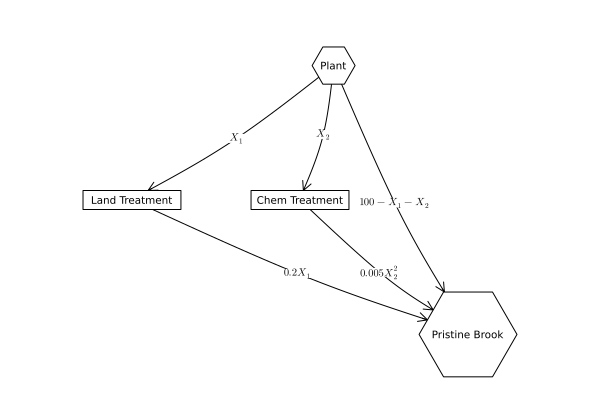

In [26]:
A = [0 1 1 1;
    0 0 0 1;
    0 0 0 1;
    0 0 0 0]

names = ["Plant", "Land Treatment", "Chem Treatment", "Pristine Brook"]
# modify this dictionary to add labels
edge_labels = Dict((1, 2) => L"X_1", (1, 3) => L"X_2", (1, 4) => L"100 - X_1 - X_2", (2, 4) => L"0.2 X_1", 
                   (3, 4) => L"0.005 X_2^2")
shapes = [:hexagon, :rect, :rect, :hexagon]
xpos = [0, -1.5, -0.25, 1]
ypos = [1, 0, 0, -1]

p = graphplot(A, names = names, edgelabel = edge_labels, markersize = 0.15, 
              markershapes = shapes, markercolor = :white, x = xpos, y = ypos)
display(p)

#### Problem 2.1

Formulate a mathematical model for the treatment cost and the amount of
YUK that will be discharged into Pristine Brook based on the wastewater
allocations. This is best done with some equations and supporting text
explaining the derivation. Make sure you include, as additional
equations in the model, any needed constraints on relevant values. You
can find some basics on writing mathematical equations using the LaTeX
typesetting syntax
[here](https://viveks.me/environmental-systems-analysis/tutorials/latex-notebook.qmd),
and a cheatsheet with LaTeX commands can be found on the course
website’s [Resources
page](https://viveks.me/environmental-systems-analysis/resources/markdown.qmd).

Based on the information and the graph given, we know that there are three ways of discahrge into Pristine Brook.
1. Land disposal: The amount of wastewater going in from the plant is $X_1$ $\text{m}^3$/day, and given the concentration of YUK is $1$ kg/$\text{m}^3$, we have a total of $X_1$ kg/day of YUK. In addition, given only 20% of the YUK applied here will go into the stream, we have $0.2X_1$ kg/day of YUK drained into Pristine Brook from method 1. The cost is given as $X_1^2/20$ dollars/day.
2. Chemical treatment: The amount of wastewater going in is $X_2$ $\text{m}^3$/day, so the amount of YUK is $X_2$ kg/day. Given the efficiency equation $e = 1 - 0.005X_2$, with `e` being the percentage of YUK removed, the percentage of YUK drained into the stream is $1 - e = 0.005X_2$. We have thus $0.005X_2^2$ kg/day of YUK entering the stream from method 2. The cost is given as $1.5$ dollars/$\text{m}^3$ of wastewater, so it is $1.5X_2$ dollars/day.
3. Direct discharge: Given the total amount of wastewater being produced by the plant is $100$ $\text{m}^3$/day, the amount of direct wastewater discharge, without being treated, that goes straight into Pristine Brook is $100-X_1-X_2$ $\text{m}^3$/day, which is $100-X_1-X_2$ kg/day of YUK discharged directly into Pristine Brook from the plant, at no cost of course.

To summarize, the mathematical model for the treatment cost and the amount of YUK that will be discharged into Pristine Brook based on the wastewater allocations can be assigned as:
\begin{align}
\text{Minimize:} \quad & C(X_1,X_2) = \frac{X_1^2}{20} + 1.5 X_2 \quad \text{(\$/day)} \\[1mm]
\text{Subject to:} \quad 
& D(X_1,X_2) = -0.8 X_1 - X_2 + 0.005 X_2^2 + 100 \le 20 \quad \text{(YUK discharge, kg/day)} \\[1mm]
& X_1 \ge 0, \quad X_2 \ge 0, \quad X_1 + X_2 \le 100
\end{align}

#### Problem 2.2

Implement your systems model as a Julia function which computes the
resulting YUK discharge and cost for a particular treatment plan. You
can return multiple values from a function with a
[tuple](https://docs.julialang.org/en/v1/manual/functions/#Tuples-1), as
in:

In [27]:
function multiple_return_values(x, y)
    return (x + y, x * y)
end

a, b = multiple_return_values(2, 5)
@show a;
@show b;

a = 7
b = 10


To evalute the function over vectors of inputs, you can *broadcast* the
function by adding a decimal `.` before the function arguments and
accessing the resulting values by writing a *comprehension* to loop over
the individual outputs in the vector:

In [28]:
x = [1, 2, 3, 4, 5]
y = [6, 7, 8, 9, 10]

output = multiple_return_values.(x, y)
a = [out[1] for out in output]
b = [out[2] for out in output]
@show a;
@show b;

a = [7, 9, 11, 13, 15]
b = [6, 14, 24, 36, 50]


Make sure you comment your code appropriately to make it clear what is
going on and why.

In [1]:
# Function to compute YUK discharge and cost for a treatment plan
function treatment_plan(x1, x2)
    discharge = 100 - 0.8 * x1 - 0.995 * x2 # compute discharge 
    cost = x1^2 / 20 + 1.5 * x2 # compute cost
    return discharge, cost # return a tuple of two values
end

treatment_plan (generic function with 1 method)

### Writeup

#### Problem 2.3

Use your function to experiment with 1,000 different combinations of
wastewater discharge and treatment. You can do this with either a grid
search or by sampling from a [Dirichlet
distribution](https://en.wikipedia.org/wiki/Dirichlet_distribution) (a
$\text{Dirichlet}(1, n)$ distribution will generate uniformly-weighted
$n$-dimensional vectors whose components add up to 1; see the
[`Distributions.jl`
documentation](https://juliastats.org/Distributions.jl/stable/starting/)
for how to sample from probability distributions in Julia). Plot the
results of these experiments. Do any satisfy the YUK effluent standard
(plot this as well as a dashed red line). What was the cost of solutions
satisfying the standard? What can you say about the tradeoff between
treatment cost and YUK discharge? You don’t have to find an “optimal”
solution to this problem, but what do you think would be needed to find
a better solution?

In [ ]:
using Distributions, Random

n_samples = 1000
alpha = ones(3)  # Dirichlet(1,1,1) gives uniform weights
dir = Dirichlet(alpha)
samples = rand(dir, n_samples)  # 3 x 1000 matrix

# Scale samples to total wastewater (100 m³/day)
X = 100 .* samples  # still 3 x 1000

discharges = zeros(n_samples)
costs = zeros(n_samples)

for i in 1:n_samples
    x1, x2, _ = X[:, i]
    d, c = treatment_plan(x1, x2)
    discharges[i] = d
    costs[i] = c
end

using Plots

scatter(discharges, costs,
    xlabel = "YUK discharge (kg/day)",
    ylabel = "Treatment cost ($/day)",
    title = "Wastewater treatment simulations",
    label = "Simulated plans")

# Draw dashed red line for effluent standard
hline!([20], color = :red, linestyle = :dash, label = "Effluent standard")

satisfying_idx = findall(<=(20), discharges)
println("Number of solutions meeting standard: ", length(satisfying_idx))
println("Costs of solutions meeting standard: ", costs[satisfying_idx])


#### Problem 2.4

Find the strategies which minimize cost and YUK discharge (these will be
different strategies) analytically and find the values of the objective
metrics. Plot these values in the plot that you created for Problem 2.3.
How do their values compare to the spread of values that you found in
that problem? Would you select either of them (explain why or why not)?

## References

List any external references consulted, including classmates.